In [52]:
import numpy as np
import pandas as pd
import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns

from simulator import MetapopulationSIRSolver

# Load global air traffic network

In [ ]:
unit_mob = 200 # Unit mobility per routes

In [25]:
edgelist = pd.read_csv("data\\edgelist_symmetric.csv")
nodelist = pd.read_csv("data\\nodelist_connected.csv")

In [26]:
# Max. number of routes between two countries as mobility
edgelist["weight"] = edgelist["Max. Number of Routes"] * unit_mob 

In [30]:
nodelist = nodelist.set_index("ID")

node_attr_dict = {}

for i in nodelist.index:
    node_attr_dict[i] = {"country": nodelist.loc[i, "Label"], "population": nodelist.loc[i, "Population"]}

In [31]:
graph = nx.from_pandas_edgelist(edgelist, "Source", "Target", edge_attr="weight")
nx.set_node_attributes(graph, node_attr_dict)

In [39]:
np.where(nodelist["Label"] == "China")[0][0]

41

# Test run for COVID-19

Basic reproduciton number: https://doi.org/10.3961/jpmph.20.076

Recovery time: 2 weeks

In [38]:
simulator = MetapopulationSIRSolver(graph, 3.32, 14)

In [40]:
result = simulator.terminal_simulation(41, 5, 30, 3*365)
result["message"]

'A termination event occurred.'

## Time series

Text(0.5, 1.0, 'South Korea')

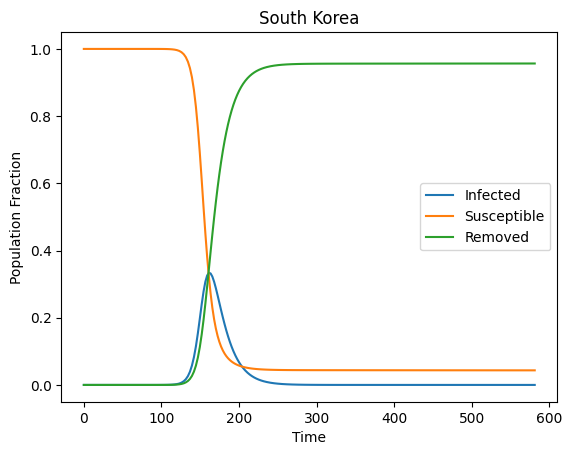

In [44]:
country = "South Korea"

node = np.where(nodelist["Label"] == country)[0][0]

plt.plot(result["t"], result["y"][node], label="Infected")
plt.plot(result["t"], result["y"][node + simulator.num_nodes], label="Susceptible")
plt.plot(result["t"], 1-result["y"][node]-result["y"][node + simulator.num_nodes], label="Removed")

plt.xlabel("Time")
plt.ylabel("Population Fraction")
plt.legend()
plt.title(country)

Text(0.5, 1.0, 'World')

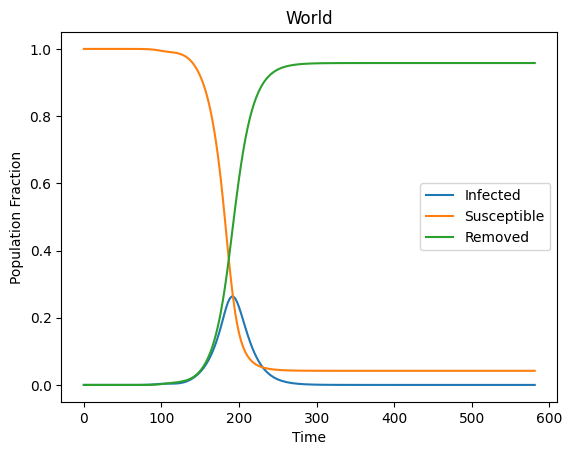

In [45]:
plt.plot(result["t"], result["I"].sum(axis=0) / simulator.total_pops.sum(), label="Infected")
plt.plot(result["t"], result["S"].sum(axis=0) / simulator.total_pops.sum(), label="Susceptible")
plt.plot(result["t"], result["R"].sum(axis=0) / simulator.total_pops.sum(), label="Removed")

plt.xlabel("Time")
plt.ylabel("Population Fraction")
plt.legend()
plt.title("World")

## Peaks

In [47]:
peaks = []

for node in graph.nodes:
    peaks.append(pd.DataFrame({
        "Country": [graph.nodes[node]["country"]],
        "Peak Severity": [result["y"][node].max()],
        "Peak Time": [result["t"][result["y"][node].argmax()]]
    }))

peaks = pd.concat(peaks)

In [56]:
peaks.sort_values(by="Peak Time", ascending=True)

,Country,Peak Severity,Peak Time
0,China,0.336537,104.916838
0,Chile,0.334953,131.393066
0,French Guiana,0.334065,134.124769
0,Australia,0.325791,139.275972
0,Zambia,0.335924,139.275972
...,...,...,...
0,Pakistan,0.335771,202.583759
0,Bolivia,0.336385,205.169003
0,Palau,0.334674,205.169003
0,Bahamas,0.333348,207.995307


In [57]:
peaks.sort_values(by="Peak Severity", ascending=True)

,Country,Peak Severity,Peak Time
0,Nauru,0.308839,172.341591
0,Brunei,0.312287,176.841792
0,Saudi Arabia,0.317432,156.597810
0,Afghanistan,0.318631,172.341591
0,Uganda,0.318772,165.596876
...,...,...,...
0,Central African Republic,0.336606,181.352864
0,Cameroon,0.336652,172.341591
0,Cape Verde,0.336682,195.181753
0,Belgium,0.336724,188.106500


c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

Text(37.722222222222214, 0.5, 'Peak severity (Maximum infected fraction)')

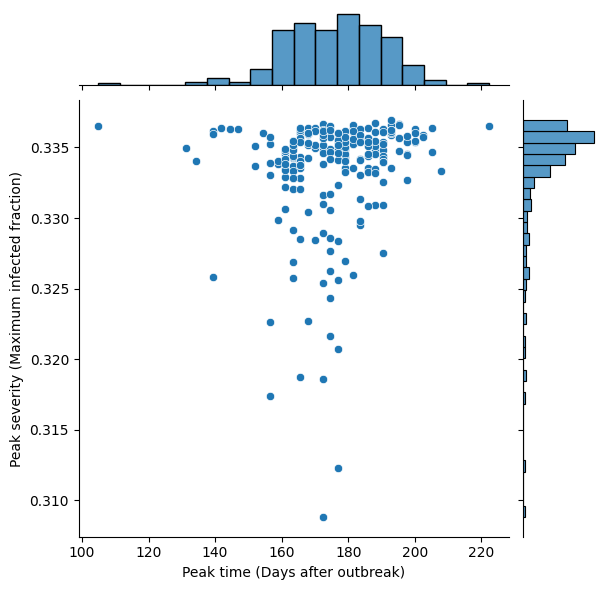

In [54]:
sns.jointplot(data=peaks, x="Peak Time", y="Peak Severity", kind="scatter")

plt.xlabel("Peak time (Days after outbreak)")
plt.ylabel("Peak severity (Maximum infected fraction)")

# Animation

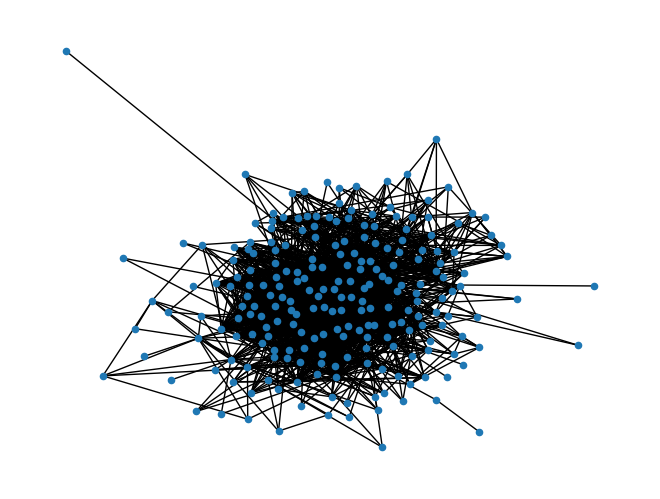

In [85]:
pos = nx.kamada_kawai_layout(graph)
nx.draw(graph, pos=pos, node_size=20)

In [78]:
max_pop = simulator.total_pops.max()
max_mob = simulator.adj_mat.max()

node_size = [(graph.nodes[node]["population"] / max_pop) ** 0.5 * 200  for node in graph.nodes]
labels = {node: graph.nodes[node]["country"] for node in graph.nodes}
max_edge_width = 5

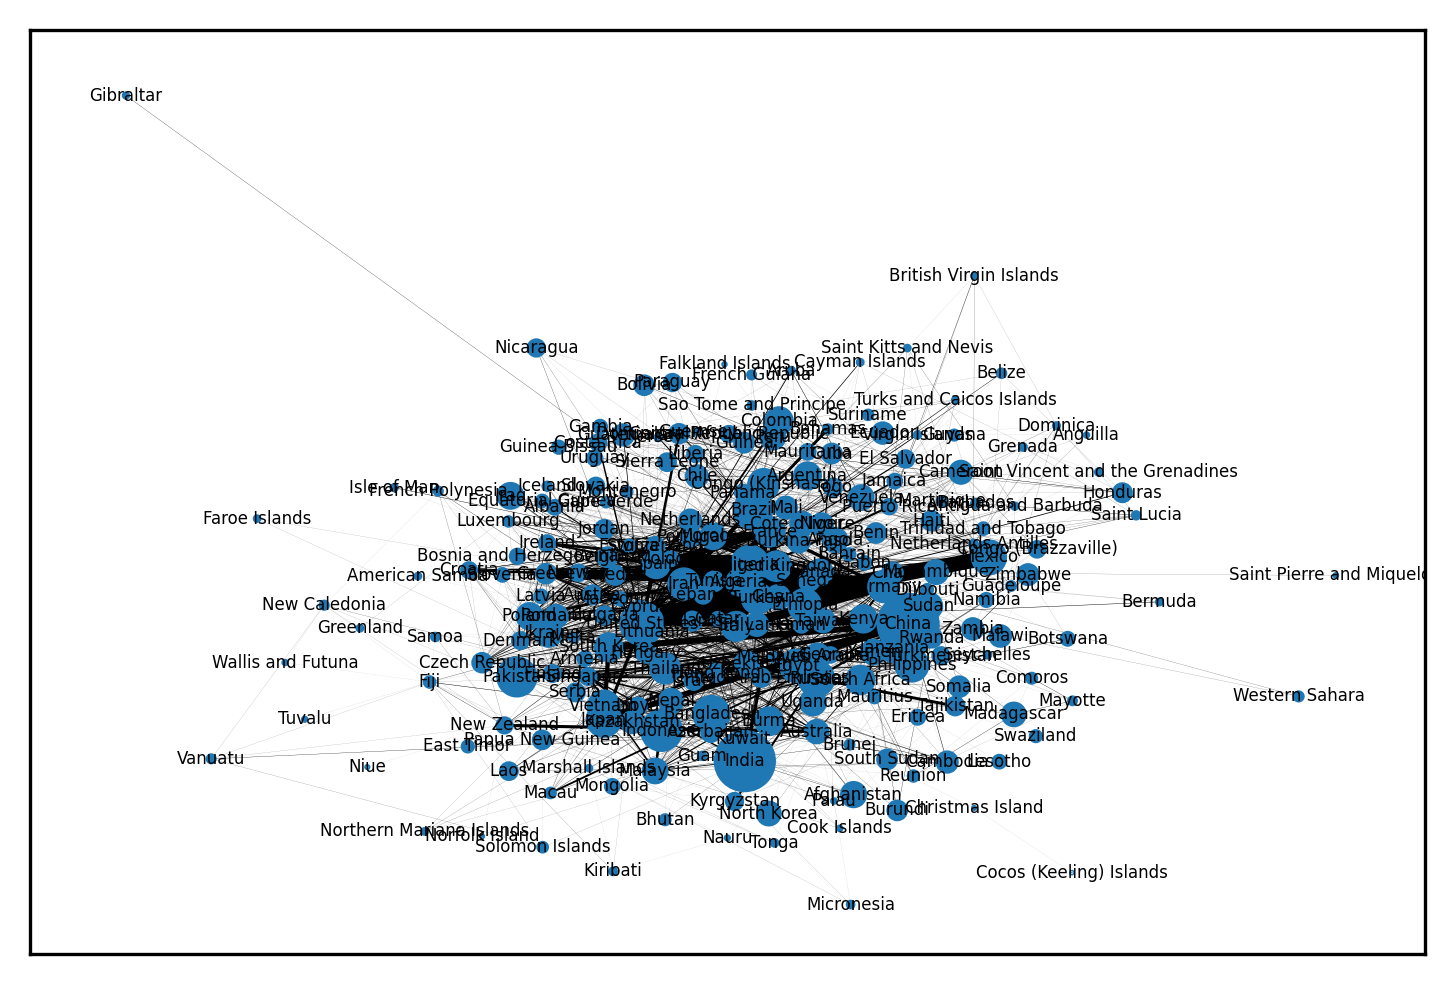

In [82]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

nx.draw_networkx(
    graph,
    ax=ax,
    pos=pos,
    node_size=node_size,
    font_size=4,
    edgelist=[],
    labels=labels
)

for edge in graph.edges(data='weight'):
    nx.draw_networkx_edges(
        graph, 
        pos, 
        ax=ax,
        edgelist=[edge], 
        width=graph[edge[0]][edge[1]]["weight"] / max_mob * max_edge_width,
    )

위경도 좌표 없이는 어렵다...